In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#1. import library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')



df = pd.read_csv("e-commerce_data.csv",encoding= 'unicode_escape' )
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
print("Raw shape:", df.shape)

Raw shape: (541909, 8)


####  Key Findings

- Analysis of 391,150 cleaned transaction records from a UK-based online gift retailer, covering December 2010 through the first nine days of December 2011.
- The United Kingdom accounts for roughly 83% of total revenue (7.24M of 8.74M), with the Netherlands, EIRE, Germany, and France as much smaller secondary markets. The five top-selling products by revenue are a mix of decorative and novelty gift items, led by "Paper Craft, Little Birdie."
- Order volume rises from Monday through Thursday, then drops on Friday; there is no recorded trading on Saturday, and Sunday volume is moderate. Within a day, orders build from mid-morning and peak around noon, staying elevated through mid-afternoon before tapering off in the evening.
- November 2011 was the single highest month for order volume. December 2011 in this dataset is a partial month (data ends December 9), so it should not be compared directly to full months.
- Quantity and revenue are strongly correlated, which follows directly from revenue being calculated as quantity multiplied by price.
- RFM segmentation split the customer base into ten groups. Hibernating is the largest single segment (1,067 customers), followed by Loyal Customer (818) and Champion (643). This suggests a meaningful re-engagement opportunity, since over a quarter of the customer base has gone quiet.

- A hybrid recommendation approach : combining text-based product similarity with co-purchase pattern similarity was built and tested; it reproduces sensible results (for example, recommending other metal lantern and hanging ornament styles for a white metal lantern search).

- Customer clustering using RFM features plus purchase-category behavior was also tested; cluster separation was modest overall, but one small, very high-value customer group emerged clearly and is worth business attention independent of the broader cluster count chosen.



#### Handle Missing values and Duplicated values

In [5]:
#1. missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
#calculate percentage of NaN rows comparing to orginal dataset
print(df['Description'].isnull().sum()/df.shape[0]*100)
print(df['CustomerID'].isnull().sum()/df.shape[0]*100)

0.2683107311375157
24.926694334288598


In [7]:
#display some NAN values for description
df[df['Description'].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom


In [8]:
#display some NAN values for customerID
df[df['CustomerID'].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom


* With the missing values
There is roughly 25% of the data is not assigned to any customer and the Nan values for description relatively has no customerID and 0 unit price -> proceed to drop NaN values



In [9]:
#drop NaN values
df = df.dropna()

In [10]:
#drop duplicate
df = df.drop_duplicates()

In [11]:
print("After dropna + dedup:", df.shape)

After dropna + dedup: (401604, 8)


#### Handle datatype

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    401604 non-null  str    
 1   StockCode    401604 non-null  str    
 2   Description  401604 non-null  str    
 3   Quantity     401604 non-null  int64  
 4   InvoiceDate  401604 non-null  str    
 5   UnitPrice    401604 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      401604 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 27.6 MB


In [13]:
#change InvoiceDate to datetime
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

#change CustomerID to int64

df['CustomerID']=df['CustomerID'].astype('int64')

In [14]:
#re-check on the datatype
df.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  str           
 1   StockCode    401604 non-null  str           
 2   Description  401604 non-null  str           
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[us]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  int64         
 7   Country      401604 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 27.6 MB


#### Flag and remove cancelled orders, non-product codes, invalid rows

In [19]:
# InvoiceNo starting with 'C' marks a cancellation.
df['OrderCancel'] = df['InvoiceNo'].apply(lambda x: int('C' in x))

# StockCodes that are entirely letters aren't physical products
# (POST, D, C2, M, DOT, CRUK, BANK CHARGES, PADS) — remove them.
df_clean = df[~df['StockCode'].str.contains('^[a-zA-Z]+', regex=True)].copy()

# Remove cancelled orders and non-positive quantity/price rows.
# Order matters: filter cancellations before quantity, since a cancelled
# order's negative quantity is a byproduct of the cancellation, not a
# separate data problem to solve.
df_clean = df_clean[(df_clean['OrderCancel'] == 0) & (df_clean['Quantity'] > 0)]
df_clean = df_clean[df_clean['UnitPrice'] > 0]
print("Final clean shape:", df_clean.shape)

Final clean shape: (391150, 9)


#### Standardise product descriptions

In [26]:
# Some StockCodes have more than one spelling of their Description
# (typos, renamed listings). Assign each StockCode its single most
# frequent Description so later grouping/recommending treats one
# physical product as one row, not several.
standardise_desc = (
    df_clean.groupby('StockCode')['Description']
    .agg(lambda x: x.value_counts().idxmax())
    .to_dict()
)
df_clean['Description_Standardise'] = df_clean['StockCode'].map(standardise_desc)

In [22]:
# Derived fields for EDA 
df_clean['SaleRevenue'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Weekday'] = df_clean['InvoiceDate'].dt.weekday
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

In [23]:
print(f"Products: {df_clean['StockCode'].nunique()}")
print(f"Invoices: {df_clean['InvoiceNo'].nunique()}")
print(f"Customers: {df_clean['CustomerID'].nunique()}")
print(f"Countries: {df_clean['Country'].nunique()}")

Products: 3659
Invoices: 18402
Customers: 4334
Countries: 37


### Visualisation 

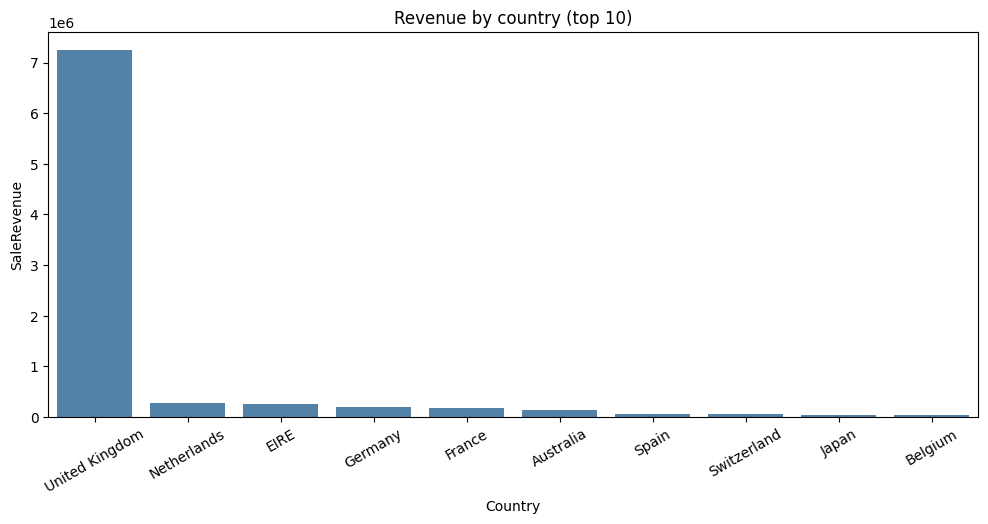

In [ ]:
#Revenue by country
country_rev = (df_clean.groupby('Country')['SaleRevenue'].sum()
               .reset_index().sort_values('SaleRevenue', ascending=False).head(10))

plt.figure(figsize=(12,5))
sns.barplot(data=country_rev, x='Country', y='SaleRevenue', color='steelblue')
plt.xticks(rotation=30)
plt.title('Revenue by country (top 10)')
plt.show()

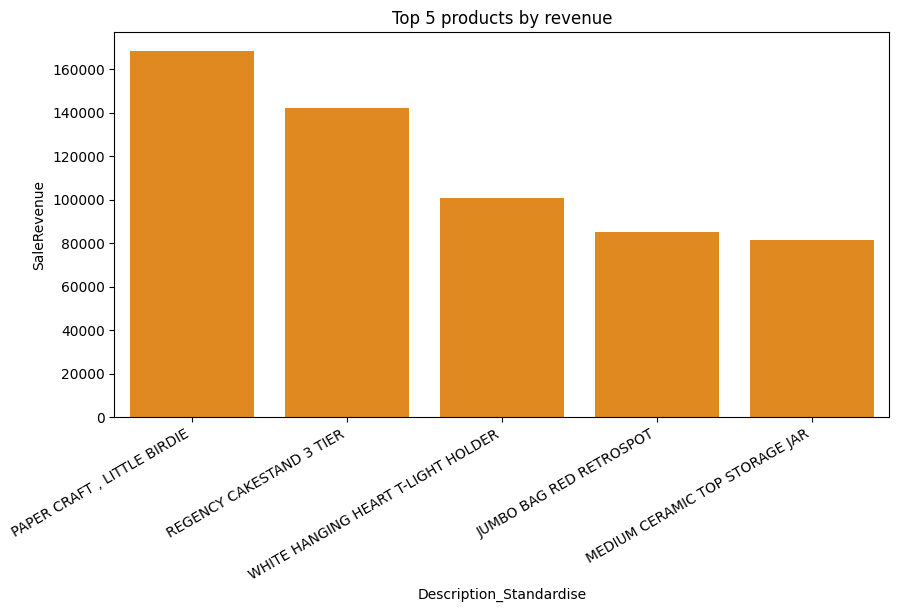

In [27]:
# Revenue by products
product_rev = (df_clean.groupby('Description_Standardise')['SaleRevenue'].sum()
               .reset_index().sort_values('SaleRevenue', ascending=False).head(5))

plt.figure(figsize=(10,5))
sns.barplot(data=product_rev, x='Description_Standardise', y='SaleRevenue', color='darkorange')
plt.xticks(rotation=30, ha='right')
plt.title('Top 5 products by revenue')
plt.show()

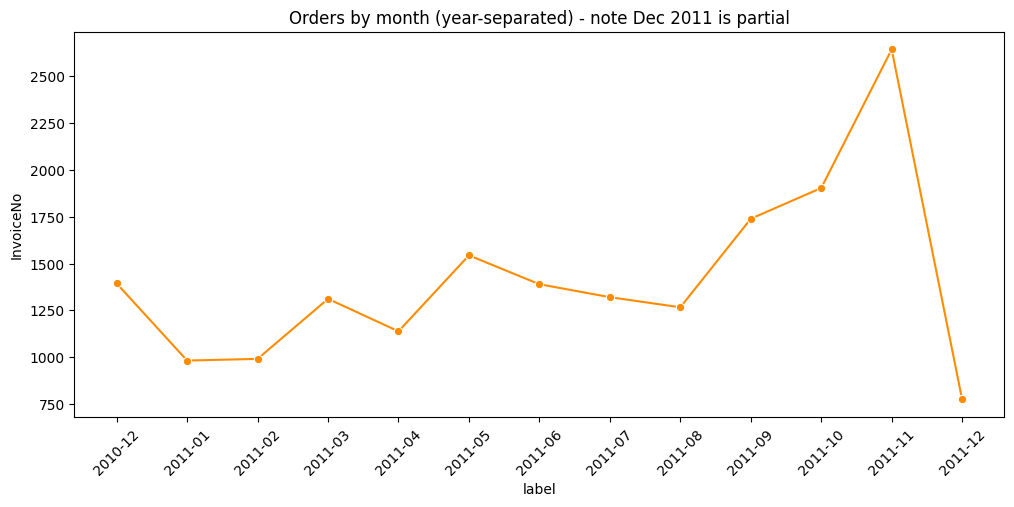

In [ ]:
#Order trend by month
order_by_yearmonth = df_clean.groupby(['Year','Month'])['InvoiceNo'].nunique().reset_index()
order_by_yearmonth['label'] = order_by_yearmonth['Year'].astype(str) + '-' + order_by_yearmonth['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(12,5))
sns.lineplot(data=order_by_yearmonth, x='label', y='InvoiceNo', marker='o', color='darkorange')
plt.xticks(rotation=45)
plt.title('Orders by month (year-separated) - note Dec 2011 is partial')
plt.show()

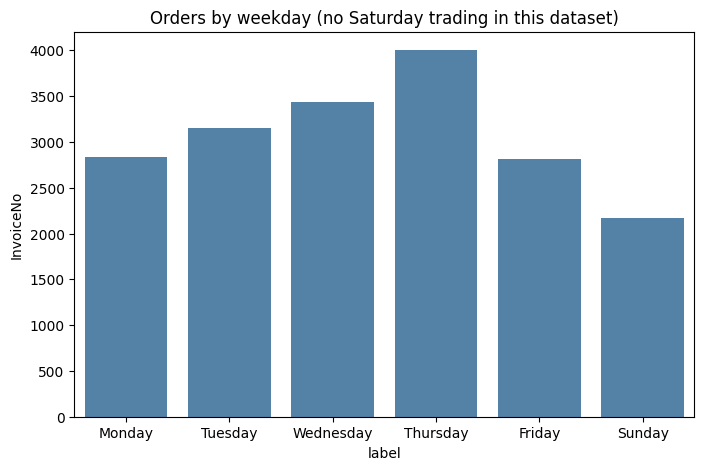

In [31]:
wd_map = {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',4:'Friday',5:'Saturday',6:'Sunday'}
order_by_weekday = df_clean.groupby('Weekday')['InvoiceNo'].nunique().reset_index()
order_by_weekday['label'] = order_by_weekday['Weekday'].map(wd_map)

plt.figure(figsize=(8,5))
sns.barplot(data=order_by_weekday, x='label', y='InvoiceNo', color='steelblue')
plt.title('Orders by weekday (no Saturday trading in this dataset)')
plt.show()

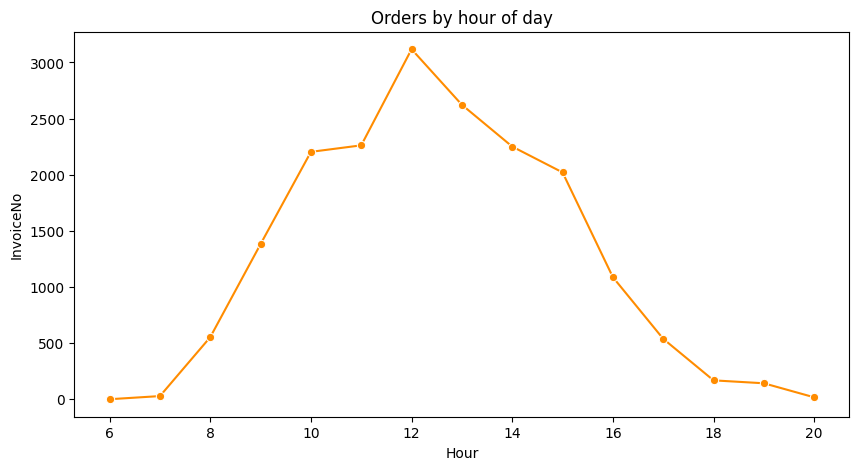

In [32]:
order_by_hour = df_clean.groupby('Hour')['InvoiceNo'].nunique().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=order_by_hour, x='Hour', y='InvoiceNo', marker='o', color='darkorange')
plt.title('Orders by hour of day')
plt.show()

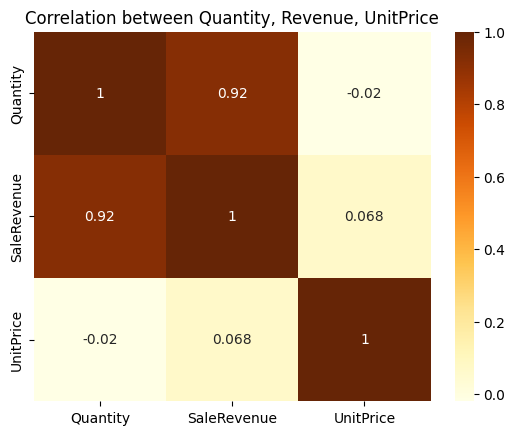

In [33]:
sns.heatmap(df_clean[['Quantity','SaleRevenue','UnitPrice']].corr(), cmap='YlOrBr', annot=True)
plt.title('Correlation between Quantity, Revenue, UnitPrice')
plt.show()

### Customer segmentation analysis

In [ ]:
#RFM feature construction
last_day = df_clean['InvoiceDate'].max()
today_date = last_day + pd.Timedelta(days=1)

df_rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda d: (today_date - d.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('SaleRevenue', 'sum')
).reset_index()

In [35]:
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1437.24
3,12349,19,1,1457.55
4,12350,310,1,294.40


In [36]:
# RFM scoring and segmentation 
df_rfm['R'] = pd.qcut(df_rfm['Recency'], 5, labels=[5,4,3,2,1], duplicates='drop')
df_rfm['F'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
df_rfm['RFM_Score'] = df_rfm['R'].astype(str) + df_rfm['F'].astype(str)

segment_map = {
    r'[1-2][1-2]':'Hibernating', r'[1-2][3-4]':'At_Risk', r'[1-2]5':'Cant_Lose',
    r'3[1-2]':'About_To_Sleep', r'33':'Need_Attention', r'[3-4][4-5]':'Loyal_Customer',
    r'41':'Promising', r'[4-5][2-3]':'Potential_Loyal', r'5[4-5]':'Champion', r'51':'New_Customer'
}
df_rfm['Segment'] = df_rfm['RFM_Score'].replace(segment_map, regex=True)
print(df_rfm['Segment'].value_counts())

Segment
Hibernating        1068
Loyal_Customer      818
Champion            643
At_Risk             574
Potential_Loyal     492
About_To_Sleep      347
Need_Attention      188
Promising            98
Cant_Lose            63
New_Customer         43
Name: count, dtype: int64


### Product recommender

In [37]:
# Build the content-based similarity matrix 
df_rec = df_clean.drop_duplicates(subset='StockCode')[['StockCode','Description_Canonical']].reset_index(drop=True)

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_rec['Description_Canonical'])
content_sim = cosine_similarity(tfidf_matrix)   # shape: (n_products, n_products)

stock_index = {s: i for i, s in enumerate(df_rec['StockCode'])}
inv_stock_index = {i: s for s, i in stock_index.items()}

In [38]:
# Build the collaborative (co-purchase) similarity matrix 
# Customer-item matrix: rows = customers, columns = products, values = quantity bought.
# Built as a sparse matrix since most customers buy a small fraction of the catalog.
cust_ids = df_clean['CustomerID'].unique()
cust_index = {c: i for i, c in enumerate(cust_ids)}

rows = df_clean['CustomerID'].map(cust_index)
cols = df_clean['StockCode'].map(stock_index)
vals = df_clean['Quantity']

cust_item_matrix = csr_matrix((vals, (rows, cols)), shape=(len(cust_index), len(stock_index)))

# Item-item similarity from co-purchase patterns: transpose so items are rows,
# then cosine similarity between item columns of the customer-item matrix.
collab_sim = cosine_similarity(cust_item_matrix.T, dense_output=False)

In [39]:
# Hybrid recommendation function 
def recommend_hybrid(stock_code, top_n=5, w_content=0.5, w_collab=0.5):
    idx = stock_index[stock_code]

    content_scores = content_sim[idx]
    collab_scores = np.asarray(collab_sim[idx].todense()).flatten()

    # Cold start: if a product has no purchase history in the co-purchase
    # matrix, its collaborative row is all zeros, fall back to content only.
    if collab_scores.sum() == 0:
        hybrid_scores = content_scores
    else:
        hybrid_scores = w_content * content_scores + w_collab * collab_scores

    top_idx = np.argsort(-hybrid_scores)[1:top_n+1]  # skip index 0 = itself
    results = [(inv_stock_index[i], standardise_desc[inv_stock_index[i]], round(hybrid_scores[i], 3))
               for i in top_idx]
    return pd.DataFrame(results, columns=['StockCode','Description','Score'])

In [41]:
recommend_hybrid('71053')  

,StockCode,Description,Score
0,22465,HANGING METAL STAR LANTERN,0.381
1,22464,HANGING METAL HEART LANTERN,0.380
2,22224,WHITE LOVEBIRD LANTERN,0.364
3,71038,WHITE HANGING BEADS CANDLE HOLDER,0.276
4,23099,FRENCH CARRIAGE LANTERN,0.262


### Using K-means clustering 

Step : 

- Build category tags. The dataset has no official product category column --> scan cleaned Descriptions for keywords (bag, box, candle/t-light, holder, jewellery, kitchen/tableware, decoration, card/stationery, garden, christmas) and tag each product with the first matching category, else "other." 
- Compute per-customer category share of spend , for each customer, what fraction of their total spend went to each category.
- Join RFM features with category shares into one feature table, one row per customer.
- Standardize features (StandardScaler) , because Recency is in days (tens to hundreds), Monetary is in pounds (tens to thousands), and category shares are in [0,1]. K-means uses Euclidean distance, so unscaled features would let Monetary dominate the distance calculation because of its larger numeric range
- Choose the number of clusters (k) using silhouette score across a range of k
- Fit K-means at the chosen k, then profile each cluster by its mean feature values

In [44]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,OrderCancel,Description_Canonical,SaleRevenue,Year,Month,Weekday,Hour,Description_Standardise,Category
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,0,WHITE HANGING HEART T-LIGHT HOLDER,15.30,2010,12,2,8,WHITE HANGING HEART T-LIGHT HOLDER,candle_light
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0,WHITE METAL LANTERN,20.34,2010,12,2,8,WHITE METAL LANTERN,other
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,0,CREAM CUPID HEARTS COAT HANGER,22.00,2010,12,2,8,CREAM CUPID HEARTS COAT HANGER,kitchen_tableware
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0,KNITTED UNION FLAG HOT WATER BOTTLE,20.34,2010,12,2,8,KNITTED UNION FLAG HOT WATER BOTTLE,other
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0,RED WOOLLY HOTTIE WHITE HEART.,20.34,2010,12,2,8,RED WOOLLY HOTTIE WHITE HEART.,other


In [43]:
# Build product category tags ====
category_keywords = {
    'bag': ['bag'],
    'box': ['box'],
    'candle_light': ['candle','t-light','tlight'],
    'holder': ['holder'],
    'jewellery': ['necklace','bracelet'],
    'kitchen_tableware': ['mug','cake','cup','teapot','plate'],
    'decoration': ['decoration','ornament'],
    'card_stationery': ['card','paper'],
    'garden': ['garden'],
    'christmas': ['christmas'],
}

def tag_category(desc):
    d = str(desc).lower()
    for cat, kws in category_keywords.items():
        if any(kw in d for kw in kws):
            return cat
    return 'other'

df_clean['Category'] = df_clean['Description_Standardise'].apply(tag_category)

In [45]:
# Per-customer category share of spend ====
cat_spend = df_clean.pivot_table(index='CustomerID', columns='Category',
                                  values='SaleRevenue', aggfunc='sum', fill_value=0)
cat_share = cat_spend.div(cat_spend.sum(axis=1), axis=0)
cat_share.columns = ['share_' + c for c in cat_share.columns]

In [46]:
cat_share

,share_bag,share_box,share_candle_light,share_card_stationery,share_christmas,share_decoration,share_garden,share_holder,share_jewellery,share_kitchen_tableware,share_other
CustomerID,,,,,,,,,,,
12346,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000
12347,0.106659,0.035429,0.035100,0.111439,0.002367,0.000000,0.000000,0.003480,0.00000,0.143121,0.562406
12348,0.000000,0.000000,0.000000,0.121065,0.000000,0.000000,0.000000,0.000000,0.00000,0.232112,0.646823
12349,0.009056,0.157662,0.032520,0.000000,0.006998,0.010291,0.000000,0.000000,0.00000,0.087544,0.695928
12350,0.069293,0.050951,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.879755
...,...,...,...,...,...,...,...,...,...,...,...
18280,0.082226,0.000000,0.000000,0.130676,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.787099
18281,0.204157,0.000000,0.000000,0.187082,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.608760
18282,0.000000,0.000000,0.000000,0.127717,0.000000,0.000000,0.000000,0.000000,0.00000,0.518955,0.353328


In [47]:
# Combine RFM with category features ====
rfm_features = df_rfm.set_index('CustomerID')[['Recency','Frequency','Monetary']]
features = rfm_features.join(cat_share)
print("Feature matrix shape:", features.shape)

Feature matrix shape: (4334, 14)


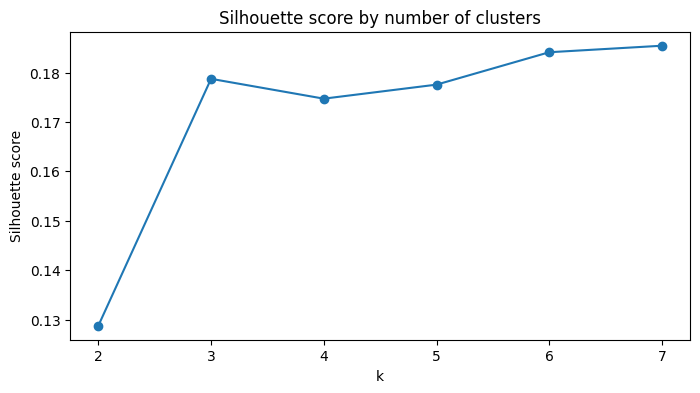

{2: 0.1287705947922287, 3: 0.17872887696423048, 4: 0.17471501868888836, 5: 0.17755347260356136, 6: 0.1841109559162935, 7: 0.18542802012866255}


In [48]:
# Scale features and choose k by silhouette score 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = StandardScaler().fit_transform(features)

sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil_scores[k] = silhouette_score(X, labels)

plt.figure(figsize=(8,4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.xlabel('k'); plt.ylabel('Silhouette score')
plt.title('Silhouette score by number of clusters')
plt.show()

print(sil_scores)

In [49]:
# Fit final model and profile clusters 
best_k = max(sil_scores, key=sil_scores.get)
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
features['Cluster'] = km.fit_predict(X)

print("Cluster sizes:\n", features['Cluster'].value_counts())
print("\nCluster profile (RFM):\n", features.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1))

Cluster sizes:
 Cluster
5    2384
1     865
3     497
2     240
6     221
4     103
0      24
Name: count, dtype: int64

Cluster profile (RFM):
          Recency  Frequency  Monetary
Cluster                              
0            6.1       69.6   87093.5
1          245.0        1.6     649.4
2           90.5        4.7    2184.3
3           76.9        2.7     874.1
4          108.3        2.3     850.9
5           38.6        5.0    1998.0
6          121.0        3.1    1247.6


# Reference :
https://clevertap.com/blog/rfm-analysis/

https://www.investopedia.com/terms/r/rfm-recency-frequency-monetary-value.asp

https://www.intelistyle.com/e-commerce-product-recommendations-guide/#:~:text=What%20Are%20Ecommerce%20Recommendations%3F,courtesy%20of%20knowledgeable%20shopping%20assistants.

https://www.bloomreach.com/en/blog/2022/why-product-recommendations-are-key-to-winning-with-e-commerce-personalization?spz=learn_orig
